# Proyecto Integrador M3 - Opción C: **agente de soporte con LangGraph**.

Integrantes:
*   William Huaquisaca
*   Aldair Llana




---


**Descripcion del caso:**


Un usuario registra una consulta de soporte. El agente debe clasificar la intencion, buscar informacion, proponer una respuesta y determinar si el caso requiere aprobacion humana. Si el caso es sensible, el flujo debe pausar, guardar checkpoint y continuar cuando exista aprobacion.


---


**Flujo minimo requerido**



1.   Recibir consulta
2.   Clasificar intencion.
13.	Recibir consulta.
14.	Clasificar intencion.
15.	Buscar informacion.
16.	Proponer respuesta.
17.	Pedir aprobacion humana si el caso es sensible.
18.	Continuar desde checkpoint.


---


**Requisitos especificos**

*   Estado minimo: ticket_id, usuario, consulta, intencion, contexto_recuperado,respuesta_propuesta, requiere_aprobacion, decision_humana, eventos.
*   Checkpoint recomendado: antes de enviar respuesta final y despues de generar la propuesta.
*   Human in the loop obligatorio: incluir una aprobacion o correccion humana simulada.
*   Demostracion esperada: mostrar pausa, revision humana y continuacion desde checkpoint.



In [ ]:
%%capture
!pip install -q langgraph typing_extensions

In [ ]:
from typing import Literal, Any
from typing_extensions import TypedDict, NotRequired, Annotated
from operator import add
from pprint import pprint

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

## Definición del estado

In [ ]:
class SupportState(TypedDict):
    ticket_id: str
    usuario: str
    consulta: str

    intencion: NotRequired[str]
    contexto_recuperado: NotRequired[str]
    respuesta_propuesta: NotRequired[str]
    requiere_aprobacion: NotRequired[bool]
    decision_humana: NotRequired[dict[str, Any]]
    respuesta_final: NotRequired[str]
    estado_ticket: NotRequired[str]

    eventos: Annotated[list[str], add]

## Base de conocimiento simulada



In [ ]:
BASE_CONOCIMIENTO = {
    "soporte_tecnico": """
Política de soporte técnico:
- Solicitar detalle del error.
- Validar usuario afectado.
- Registrar fecha y hora aproximada.
- Escalar si el sistema está caído o afecta operación crítica.
""",
    "facturacion": """
Política de facturación:
- Revisar comprobante, monto y fecha del cobro.
- Si hay cobro duplicado, no prometer devolución inmediata.
- Escalar a revisión humana antes de responder al cliente.
""",
    "cuenta": """
Política de cuenta:
- Orientar al usuario sobre recuperación de acceso.
- No solicitar contraseñas.
- Escalar si involucra datos sensibles o cambios críticos.
""",
    "general": """
Política general:
- Brindar orientación clara.
- Solicitar más información si la consulta es ambigua.
- Mantener tono profesional y trazabilidad del caso.
"""
}

## Nodos del grafo

In [ ]:
def recibir_consulta(state: SupportState) -> dict:
    """
    Nodo 1:
    Registra la recepción del ticket.
    """
    return {
        "estado_ticket": "recibido",
        "eventos": [
            f"Ticket {state['ticket_id']} recibido para el usuario {state['usuario']}."
        ]
    }


def clasificar_intencion(state: SupportState) -> dict:
    """
    Nodo 2:
    Clasifica la intención de la consulta.
    """
    texto = state["consulta"].lower()

    if any(p in texto for p in ["error", "falla", "no funciona", "caído", "caido", "sistema"]):
        intencion = "soporte_tecnico"
    elif any(p in texto for p in ["cobro", "factura", "boleta", "pago", "duplicado", "devolución", "devolucion"]):
        intencion = "facturacion"
    elif any(p in texto for p in ["contraseña", "password", "acceso", "cuenta", "bloqueado"]):
        intencion = "cuenta"
    else:
        intencion = "general"

    return {
        "intencion": intencion,
        "eventos": [f"Intención clasificada como: {intencion}."]
    }


def buscar_informacion(state: SupportState) -> dict:
    """
    Nodo 3:
    Recupera información desde una base de conocimiento simulada.
    """
    intencion = state.get("intencion", "general")
    contexto = BASE_CONOCIMIENTO.get(intencion, BASE_CONOCIMIENTO["general"])

    return {
        "contexto_recuperado": contexto.strip(),
        "eventos": [f"Contexto recuperado para la intención: {intencion}."]
    }


def evaluar_sensibilidad(consulta: str, intencion: str) -> bool:
    """
    Regla de negocio:
    Determina si el caso requiere aprobación humana.
    """
    texto = consulta.lower()

    palabras_sensibles = [
        "cobro duplicado",
        "duplicado",
        "devolución",
        "devolucion",
        "reembolso",
        "reclamo",
        "denuncia",
        "legal",
        "demanda",
        "datos personales",
        "eliminar mi cuenta",
        "borrar mis datos",
        "compensación",
        "compensacion"
    ]

    if intencion == "facturacion" and any(p in texto for p in palabras_sensibles):
        return True

    if any(p in texto for p in ["legal", "demanda", "denuncia", "datos personales", "borrar mis datos"]):
        return True

    return False


def proponer_respuesta(state: SupportState) -> dict:
    """
    Nodo 4:
    Genera una respuesta propuesta y determina si requiere aprobación humana.
    """
    intencion = state["intencion"]
    consulta = state["consulta"]

    requiere_aprobacion = evaluar_sensibilidad(consulta, intencion)

    if intencion == "soporte_tecnico":
        respuesta = (
            "Hemos registrado tu caso técnico. Para continuar, necesitamos validar "
            "el detalle del error, el usuario afectado y la hora aproximada del incidente. "
            "Si el sistema está caído, el caso será priorizado."
        )

    elif intencion == "facturacion":
        respuesta = (
            "Hemos registrado tu consulta de facturación. Revisaremos el comprobante, "
            "el monto y la fecha del cobro. Si se confirma un posible cobro duplicado, "
            "el caso será derivado a revisión antes de emitir una respuesta definitiva."
        )

    elif intencion == "cuenta":
        respuesta = (
            "Te ayudaremos con el acceso a tu cuenta. Por seguridad, no debes compartir "
            "contraseñas. Validaremos tu identidad por los canales autorizados."
        )

    else:
        respuesta = (
            "Gracias por contactarnos. Para ayudarte mejor, necesitamos que nos brindes "
            "más detalle sobre tu consulta."
        )

    return {
        "respuesta_propuesta": respuesta,
        "requiere_aprobacion": requiere_aprobacion,
        "estado_ticket": "respuesta_propuesta_generada",
        "eventos": [
            f"Respuesta propuesta generada. Requiere aprobación humana: {requiere_aprobacion}."
        ]
    }

## Ruteo condicional



In [ ]:
def decidir_si_requiere_aprobacion(
    state: SupportState
) -> Literal["aprobacion_humana", "enviar_respuesta_final"]:
    """
    Decide si el flujo continúa directo o se pausa para aprobación humana.
    """
    if state.get("requiere_aprobacion", False):
        return "aprobacion_humana"

    return "enviar_respuesta_final"

## Nodo Human-in-the-loop

In [ ]:
def aprobacion_humana(state: SupportState) -> dict:
    """
    Nodo 5:
    Pausa el grafo y espera decisión humana.

    Este interrupt genera el checkpoint.
    Luego se continúa con Command(resume=...).
    """

    decision = interrupt({
        "mensaje": "El caso requiere aprobación humana antes de enviar la respuesta final.",
        "ticket_id": state["ticket_id"],
        "usuario": state["usuario"],
        "consulta": state["consulta"],
        "intencion": state["intencion"],
        "respuesta_propuesta": state["respuesta_propuesta"],
        "instruccion": (
            "Responder con {'aprobado': True/False, "
            "'comentario': '...', 'respuesta_corregida': '...'}"
        )
    })

    aprobado = decision.get("aprobado", False)
    comentario = decision.get("comentario", "")
    respuesta_corregida = decision.get("respuesta_corregida", "")

    eventos = [
        f"Decisión humana recibida. Aprobado: {aprobado}. Comentario: {comentario}"
    ]

    updates = {
        "decision_humana": decision,
        "eventos": eventos
    }

    if respuesta_corregida:
        updates["respuesta_propuesta"] = respuesta_corregida
        updates["eventos"].append(
            "La respuesta propuesta fue corregida por el aprobador humano."
        )

    return updates

## Nodo final

In [ ]:
def enviar_respuesta_final(state: SupportState) -> dict:
    """
    Nodo 6:
    Envía o rechaza la respuesta final según la aprobación humana.
    """

    requiere_aprobacion = state.get("requiere_aprobacion", False)
    decision_humana = state.get("decision_humana", {})

    if requiere_aprobacion:
        if not decision_humana:
            return {
                "estado_ticket": "pendiente_aprobacion",
                "eventos": ["El ticket sigue pendiente de aprobación humana."]
            }

        if decision_humana.get("aprobado", False):
            respuesta_final = state["respuesta_propuesta"]
            estado_ticket = "respondido_con_aprobacion"
            evento = "Respuesta final enviada luego de aprobación humana."
        else:
            respuesta_final = (
                "Tu caso fue registrado y será revisado por un especialista antes de emitir "
                "una respuesta definitiva."
            )
            estado_ticket = "derivado_a_revision"
            evento = "La respuesta no fue aprobada. El ticket fue derivado a revisión."
    else:
        respuesta_final = state["respuesta_propuesta"]
        estado_ticket = "respondido_automaticamente"
        evento = "Respuesta final enviada automáticamente, sin aprobación humana."

    return {
        "respuesta_final": respuesta_final,
        "estado_ticket": estado_ticket,
        "eventos": [evento]
    }

## Construcción y compilación del grafo

In [ ]:
def construir_grafo_soporte():
    builder = StateGraph(SupportState)

    builder.add_node("recibir_consulta", recibir_consulta)
    builder.add_node("clasificar_intencion", clasificar_intencion)
    builder.add_node("buscar_informacion", buscar_informacion)
    builder.add_node("proponer_respuesta", proponer_respuesta)
    builder.add_node("aprobacion_humana", aprobacion_humana)
    builder.add_node("enviar_respuesta_final", enviar_respuesta_final)

    builder.add_edge(START, "recibir_consulta")
    builder.add_edge("recibir_consulta", "clasificar_intencion")
    builder.add_edge("clasificar_intencion", "buscar_informacion")
    builder.add_edge("buscar_informacion", "proponer_respuesta")

    builder.add_conditional_edges(
        "proponer_respuesta",
        decidir_si_requiere_aprobacion
    )

    builder.add_edge("aprobacion_humana", "enviar_respuesta_final")
    builder.add_edge("enviar_respuesta_final", END)

    checkpointer = InMemorySaver()
    graph = builder.compile(checkpointer=checkpointer)

    return graph


support_graph = construir_grafo_soporte()

## Visualización del grafo

In [ ]:
print(support_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	recibir_consulta(recibir_consulta)
	clasificar_intencion(clasificar_intencion)
	buscar_informacion(buscar_informacion)
	proponer_respuesta(proponer_respuesta)
	aprobacion_humana(aprobacion_humana)
	enviar_respuesta_final(enviar_respuesta_final)
	__end__([<p>__end__</p>]):::last
	__start__ --> recibir_consulta;
	aprobacion_humana --> enviar_respuesta_final;
	buscar_informacion --> proponer_respuesta;
	clasificar_intencion --> buscar_informacion;
	proponer_respuesta -.-> aprobacion_humana;
	proponer_respuesta -.-> enviar_respuesta_final;
	recibir_consulta --> clasificar_intencion;
	enviar_respuesta_final --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



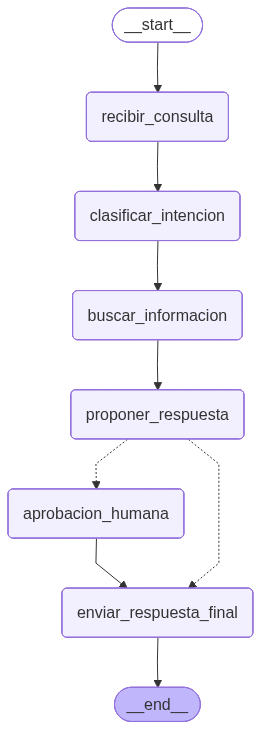

In [ ]:
from IPython.display import Image, display

try:
    display(Image(support_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("No se pudo renderizar el PNG del grafo en este entorno.")
    print(e)

## Funciones auxiliares para revisar estado e historial

In [ ]:
def mostrar_estado_actual(graph, config, titulo="ESTADO ACTUAL"):
    print("\n" + "=" * 80)
    print(titulo)
    print("=" * 80)

    estado = graph.get_state(config)

    print("\nValores del estado:")
    pprint(estado.values)

    print("\nPróximo nodo:")
    print(estado.next)


def mostrar_historial_checkpoints(graph, config, titulo="HISTORIAL DE CHECKPOINTS"):
    print("\n" + "=" * 80)
    print(titulo)
    print("=" * 80)

    historial = list(graph.get_state_history(config))

    print(f"\nCantidad de checkpoints guardados: {len(historial)}")

    for i, snapshot in enumerate(reversed(historial), start=1):
        print("\n" + "-" * 80)
        print(f"Checkpoint lógico #{i}")
        print("Siguiente nodo:", snapshot.next)
        print("Estado:")
        pprint(snapshot.values)


def mostrar_resumen_ejecucion(graph, config):
    estado = graph.get_state(config)
    historial = list(graph.get_state_history(config))

    print("\n" + "=" * 80)
    print("RESUMEN DEL THREAD")
    print("=" * 80)

    print("Thread ID:", config["configurable"]["thread_id"])

    print("\nEstado final:")
    pprint(estado.values)

    print("\nPróximo nodo:")
    print(estado.next)

    print("\nEventos:")
    for evento in estado.values.get("eventos", []):
        print("-", evento)

    print("\nCheckpoints guardados:")
    print(len(historial))

## Demo 1 — Caso normal sin aprobación humana

Este caso no es sensible. El agente responde automáticamente.


In [ ]:
ticket_normal = {
    "ticket_id": "TK-001",
    "usuario": "Juan Pérez",
    "consulta": "Tengo un error al ingresar al sistema desde la mañana.",
    "eventos": []
}

config_normal = {
    "configurable": {
        "thread_id": "thread-ticket-normal-001"
    }
}

resultado_normal = support_graph.invoke(ticket_normal, config_normal)

print("=== RESULTADO CASO NORMAL ===")
pprint(resultado_normal)

=== RESULTADO CASO NORMAL ===
{'consulta': 'Tengo un error al ingresar al sistema desde la mañana.',
 'contexto_recuperado': 'Política de soporte técnico:\n'
                        '- Solicitar detalle del error.\n'
                        '- Validar usuario afectado.\n'
                        '- Registrar fecha y hora aproximada.\n'
                        '- Escalar si el sistema está caído o afecta operación '
                        'crítica.',
 'estado_ticket': 'respondido_automaticamente',
 'eventos': ['Ticket TK-001 recibido para el usuario Juan Pérez.',
             'Intención clasificada como: soporte_tecnico.',
             'Contexto recuperado para la intención: soporte_tecnico.',
             'Respuesta propuesta generada. Requiere aprobación humana: False.',
             'Respuesta final enviada automáticamente, sin aprobación humana.'],
 'intencion': 'soporte_tecnico',
 'requiere_aprobacion': False,
 'respuesta_final': 'Hemos registrado tu caso técnico. Para continuar, 

In [ ]:
mostrar_estado_actual(support_graph, config_normal, "ESTADO FINAL - CASO NORMAL")
mostrar_historial_checkpoints(support_graph, config_normal, "CHECKPOINTS - CASO NORMAL")


ESTADO FINAL - CASO NORMAL

Valores del estado:
{'consulta': 'Tengo un error al ingresar al sistema desde la mañana.',
 'contexto_recuperado': 'Política de soporte técnico:\n'
                        '- Solicitar detalle del error.\n'
                        '- Validar usuario afectado.\n'
                        '- Registrar fecha y hora aproximada.\n'
                        '- Escalar si el sistema está caído o afecta operación '
                        'crítica.',
 'estado_ticket': 'respondido_automaticamente',
 'eventos': ['Ticket TK-001 recibido para el usuario Juan Pérez.',
             'Intención clasificada como: soporte_tecnico.',
             'Contexto recuperado para la intención: soporte_tecnico.',
             'Respuesta propuesta generada. Requiere aprobación humana: False.',
             'Respuesta final enviada automáticamente, sin aprobación humana.'],
 'intencion': 'soporte_tecnico',
 'requiere_aprobacion': False,
 'respuesta_final': 'Hemos registrado tu caso técnic

## Demo 2 — Caso sensible con pausa humana



In [ ]:
ticket_sensible = {
    "ticket_id": "TK-002",
    "usuario": "María López",
    "consulta": (
        "Me hicieron un cobro duplicado y exijo devolución inmediata. "
        "Esto es un reclamo urgente."
    ),
    "eventos": []
}

config_sensible = {
    "configurable": {
        "thread_id": "thread-ticket-sensible-002"
    }
}

resultado_pausa = support_graph.invoke(ticket_sensible, config_sensible)

print("=== RESULTADO TRAS PRIMERA EJECUCIÓN: PAUSA HUMANA ===")
pprint(resultado_pausa)

=== RESULTADO TRAS PRIMERA EJECUCIÓN: PAUSA HUMANA ===
{'__interrupt__': [Interrupt(value={'consulta': 'Me hicieron un cobro '
                                                'duplicado y exijo devolución '
                                                'inmediata. Esto es un reclamo '
                                                'urgente.',
                                    'instruccion': "Responder con {'aprobado': "
                                                   "True/False, 'comentario': "
                                                   "'...', "
                                                   "'respuesta_corregida': "
                                                   "'...'}",
                                    'intencion': 'facturacion',
                                    'mensaje': 'El caso requiere aprobación '
                                               'humana antes de enviar la '
                                               'respuesta final.',
       

In [ ]:
mostrar_estado_actual(support_graph, config_sensible, "ESTADO PAUSADO - CASO SENSIBLE")
mostrar_historial_checkpoints(
    support_graph,
    config_sensible,
    "CHECKPOINTS ANTES DE APROBACIÓN HUMANA"
)


ESTADO PAUSADO - CASO SENSIBLE

Valores del estado:
{'consulta': 'Me hicieron un cobro duplicado y exijo devolución inmediata. '
             'Esto es un reclamo urgente.',
 'contexto_recuperado': 'Política de facturación:\n'
                        '- Revisar comprobante, monto y fecha del cobro.\n'
                        '- Si hay cobro duplicado, no prometer devolución '
                        'inmediata.\n'
                        '- Escalar a revisión humana antes de responder al '
                        'cliente.',
 'estado_ticket': 'respuesta_propuesta_generada',
 'eventos': ['Ticket TK-002 recibido para el usuario María López.',
             'Intención clasificada como: facturacion.',
             'Contexto recuperado para la intención: facturacion.',
             'Respuesta propuesta generada. Requiere aprobación humana: True.'],
 'intencion': 'facturacion',
 'requiere_aprobacion': True,
 'respuesta_propuesta': 'Hemos registrado tu consulta de facturación. '
              

## Continuar desde checkpoint con aprobación humana

Aquí se simula que un aprobador humano revisa la respuesta, la aprueba y la corrige.


In [ ]:
decision_aprobador = {
    "aprobado": True,
    "comentario": (
        "Se aprueba la respuesta, pero debe evitar prometer devolución inmediata."
    ),
    "respuesta_corregida": (
        "Hemos registrado tu reclamo por posible cobro duplicado. "
        "El caso será revisado por el equipo de facturación validando comprobante, "
        "monto y fecha del cargo. Luego de la revisión, se te informará el resultado "
        "por el canal registrado."
    )
}

resultado_final_sensible = support_graph.invoke(
    Command(resume=decision_aprobador),
    config_sensible
)

print("=== RESULTADO FINAL LUEGO DE APROBACIÓN HUMANA ===")
pprint(resultado_final_sensible)

=== RESULTADO FINAL LUEGO DE APROBACIÓN HUMANA ===
{'consulta': 'Me hicieron un cobro duplicado y exijo devolución inmediata. '
             'Esto es un reclamo urgente.',
 'contexto_recuperado': 'Política de facturación:\n'
                        '- Revisar comprobante, monto y fecha del cobro.\n'
                        '- Si hay cobro duplicado, no prometer devolución '
                        'inmediata.\n'
                        '- Escalar a revisión humana antes de responder al '
                        'cliente.',
 'decision_humana': {'aprobado': True,
                     'comentario': 'Se aprueba la respuesta, pero debe evitar '
                                   'prometer devolución inmediata.',
                     'respuesta_corregida': 'Hemos registrado tu reclamo por '
                                            'posible cobro duplicado. El caso '
                                            'será revisado por el equipo de '
                                            'f

In [ ]:
mostrar_estado_actual(support_graph, config_sensible, "ESTADO FINAL - CASO SENSIBLE")
mostrar_historial_checkpoints(support_graph, config_sensible, "CHECKPOINTS FINALES - CASO SENSIBLE")
mostrar_resumen_ejecucion(support_graph, config_sensible)


ESTADO FINAL - CASO SENSIBLE

Valores del estado:
{'consulta': 'Me hicieron un cobro duplicado y exijo devolución inmediata. '
             'Esto es un reclamo urgente.',
 'contexto_recuperado': 'Política de facturación:\n'
                        '- Revisar comprobante, monto y fecha del cobro.\n'
                        '- Si hay cobro duplicado, no prometer devolución '
                        'inmediata.\n'
                        '- Escalar a revisión humana antes de responder al '
                        'cliente.',
 'decision_humana': {'aprobado': True,
                     'comentario': 'Se aprueba la respuesta, pero debe evitar '
                                   'prometer devolución inmediata.',
                     'respuesta_corregida': 'Hemos registrado tu reclamo por '
                                            'posible cobro duplicado. El caso '
                                            'será revisado por el equipo de '
                                            'f

## Demo 3 — Caso sensible no aprobado

Este caso muestra que el humano puede rechazar la respuesta automática y derivar el ticket.


In [ ]:
ticket_no_aprobado = {
    "ticket_id": "TK-003",
    "usuario": "Carlos Rojas",
    "consulta": (
        "Quiero denunciar un cobro duplicado. "
        "Si no me devuelven hoy, haré una demanda."
    ),
    "eventos": []
}

config_no_aprobado = {
    "configurable": {
        "thread_id": "thread-ticket-no-aprobado-003"
    }
}

resultado_pausa_no_aprobado = support_graph.invoke(ticket_no_aprobado, config_no_aprobado)

print("=== RESULTADO PAUSADO - CASO NO APROBADO ===")
pprint(resultado_pausa_no_aprobado)

=== RESULTADO PAUSADO - CASO NO APROBADO ===
{'__interrupt__': [Interrupt(value={'consulta': 'Quiero denunciar un cobro '
                                                'duplicado. Si no me devuelven '
                                                'hoy, haré una demanda.',
                                    'instruccion': "Responder con {'aprobado': "
                                                   "True/False, 'comentario': "
                                                   "'...', "
                                                   "'respuesta_corregida': "
                                                   "'...'}",
                                    'intencion': 'facturacion',
                                    'mensaje': 'El caso requiere aprobación '
                                               'humana antes de enviar la '
                                               'respuesta final.',
                                    'respuesta_propuesta': 'Hemos registrado '

In [ ]:
decision_rechazo = {
    "aprobado": False,
    "comentario": (
        "No aprobar respuesta automática. El caso tiene riesgo legal "
        "y debe revisarlo un especialista."
    ),
    "respuesta_corregida": ""
}

resultado_no_aprobado = support_graph.invoke(
    Command(resume=decision_rechazo),
    config_no_aprobado
)

print("=== RESULTADO FINAL - CASO NO APROBADO ===")
pprint(resultado_no_aprobado)

=== RESULTADO FINAL - CASO NO APROBADO ===
{'consulta': 'Quiero denunciar un cobro duplicado. Si no me devuelven hoy, '
             'haré una demanda.',
 'contexto_recuperado': 'Política de facturación:\n'
                        '- Revisar comprobante, monto y fecha del cobro.\n'
                        '- Si hay cobro duplicado, no prometer devolución '
                        'inmediata.\n'
                        '- Escalar a revisión humana antes de responder al '
                        'cliente.',
 'decision_humana': {'aprobado': False,
                     'comentario': 'No aprobar respuesta automática. El caso '
                                   'tiene riesgo legal y debe revisarlo un '
                                   'especialista.',
                     'respuesta_corregida': ''},
 'estado_ticket': 'derivado_a_revision',
 'eventos': ['Ticket TK-003 recibido para el usuario Carlos Rojas.',
             'Intención clasificada como: facturacion.',
             'Contexto re

In [ ]:
mostrar_estado_actual(support_graph, config_no_aprobado, "ESTADO FINAL - CASO NO APROBADO")
mostrar_historial_checkpoints(support_graph, config_no_aprobado, "CHECKPOINTS - CASO NO APROBADO")


ESTADO FINAL - CASO NO APROBADO

Valores del estado:
{'consulta': 'Quiero denunciar un cobro duplicado. Si no me devuelven hoy, '
             'haré una demanda.',
 'contexto_recuperado': 'Política de facturación:\n'
                        '- Revisar comprobante, monto y fecha del cobro.\n'
                        '- Si hay cobro duplicado, no prometer devolución '
                        'inmediata.\n'
                        '- Escalar a revisión humana antes de responder al '
                        'cliente.',
 'decision_humana': {'aprobado': False,
                     'comentario': 'No aprobar respuesta automática. El caso '
                                   'tiene riesgo legal y debe revisarlo un '
                                   'especialista.',
                     'respuesta_corregida': ''},
 'estado_ticket': 'derivado_a_revision',
 'eventos': ['Ticket TK-003 recibido para el usuario Carlos Rojas.',
             'Intención clasificada como: facturacion.',
             '